# NMF Topic Model — England k=30

**Corpus:** 3,931 articles post-cleaning (3,943 raw → cleaned by removing GOV.UK footer phrases, FFT newsletter boilerplate, and articles <200 chars)

**Sources:** SchoolsWeek (~69%), GOV.UK, FFT, EPI, Nuffield, FED

**Model:** NMF, k=30, max_features=3000, min_df=3, init=nndsvd, max_iter=1000

**Key findings:**
- 30 interpretable topics, well-distributed (range 1.1%–6.5%), no topic exceeds 7%
- 14/30 topics are >90% single-source; 11/30 have one source exceeding 88%
- Source segmentation — parallel monologues not conversation: Gov does regulation, SchoolsWeek does politics, FFT does data, Nuffield does research
- Mean dominant weight 0.130 — confident assignments across most articles
- Topic stability: 0.966 across 5 random seeds (first k where stability drops below 1.0)
- LLM naming validation: 29/30 AGREE with human-assigned names
- Coherence: 0.689 (plateau from k=15 onwards — metric cannot distinguish k=15 from k=50)


# 0. Imports

In [1]:
import sys
sys.path.insert(0, "/workspaces/AM1_topic_modelling")

import logging
import pandas as pd
import numpy as np
from pathlib import Path

logging.basicConfig(level=logging.INFO)
logging.getLogger("gensim").setLevel(logging.WARNING)

from model_pipeline.training.s02_cleaning import run_cleaning
from model_pipeline.training.s03_spacy_processing import run_spacy_processing
from model_pipeline.training.s04_vectorisation import run_vectorisation
from model_pipeline.training.s05_nmf_training import run_nmf_training, get_top_words_per_topic

from sklearn.decomposition import NMF
from sklearn.metrics.pairwise import cosine_similarity


# 1. Load England training data (full)

In [2]:
preprocessed_path = Path("/workspaces/AM1_topic_modelling/data/training/eng_training_preprocessed.parquet")

if preprocessed_path.exists():
    print("Loading preprocessed data (skipping cleaning + spaCy)...")
    df = pd.read_parquet(preprocessed_path)
    SKIP_PREPROCESSING = True
else:
    csv_path = Path("/workspaces/AM1_topic_modelling/data/training/eng_training.csv")
    df = pd.read_csv(csv_path)
    SKIP_PREPROCESSING = False

print(f"Loaded: {df.shape}")
print(f"Skip preprocessing: {SKIP_PREPROCESSING}")


Loading preprocessed data (skipping cleaning + spaCy)...
Loaded: (3943, 18)
Skip preprocessing: True


# 2. Prepare text column

The Supabase schema has `title` and `text` as separate columns. The pipeline expects a combined `text` column. Also rename `article_date` → `date` to match pipeline expectations.

In [3]:
if not SKIP_PREPROCESSING:
    # Combine title + text (same as s01_data_loader)
    df["text"] = df["title"].fillna("") + "\n\n" + df["text"].fillna("")
    df["date"] = pd.to_datetime(df["article_date"], errors="coerce")
    print(f"Text combined. Sample length: {df['text'].str.len().describe()}")
else:
    print("Skipped — using preprocessed data")

Skipped — using preprocessed data


# 3. Cleaning (s02)

In [4]:
if not SKIP_PREPROCESSING:
    df = run_cleaning(df)
    print(f"After cleaning: {df.shape}")
    print(f"Empty text_clean: {(df['text_clean'].str.len() == 0).sum()}")
else:
    print("Skipped — using preprocessed data")

Skipped — using preprocessed data


# 4. spaCy processing (s03)

This takes a few minutes on ~4k articles.

In [5]:
if not SKIP_PREPROCESSING:
    df = run_spacy_processing(df)
    print(f"After spaCy: {df.shape}")
    print(f"Empty text_final: {(df['text_final'].str.len() == 0).sum()}")
    print(f"Avg tokens per doc: {df['tokens_final'].apply(len).mean():.0f}")
else:
    print("Skipped — using preprocessed data")

Skipped — using preprocessed data


In [6]:
if not SKIP_PREPROCESSING:
    df.to_parquet("/workspaces/AM1_topic_modelling/data/training/eng_training_preprocessed.parquet")
    print(f"Saved preprocessed data: {df.shape}")
else:
    print("Already loaded from parquet")

Already loaded from parquet


# 5. TF-IDF vectorisation (s04)

In [7]:
# Using same params as config.yaml: min_df=3, max_df=0.85, max_features=3000, ngram_range=(1,2)
vec_out = run_vectorisation(df)
print(f"TF-IDF matrix: {vec_out.X.shape}")
print(f"Vocabulary size: {len(vec_out.feature_names)}")
print(f"Sample features: {vec_out.feature_names[:20].tolist()}")

INFO:model_pipeline.training.s04_vectorisation:Step 04 (vectorisation): starting. Input shape=(3943, 18)
INFO:model_pipeline.training.s04_vectorisation:TF-IDF shape: (3943, 3000)
INFO:model_pipeline.training.s04_vectorisation:Vectorizer params: min_df=3 max_df=0.85 max_features=3000 ngram_range=(1, 2)
INFO:model_pipeline.training.s04_vectorisation:Sample features: ['ab', 'ability', 'able', 'absence', 'absence absence', 'absence pupil', 'absence school', 'absent', 'absent pupil', 'absentee', 'absolute', 'abuse', 'academic', 'academies', 'academisation', 'academy', 'academy academy', 'academy financial', 'academy freedom', 'academy funding']


TF-IDF matrix: (3943, 3000)
Vocabulary size: 3000
Sample features: ['ab', 'ability', 'able', 'absence', 'absence absence', 'absence pupil', 'absence school', 'absent', 'absent pupil', 'absentee', 'absolute', 'abuse', 'academic', 'academies', 'academisation', 'academy', 'academy academy', 'academy financial', 'academy freedom', 'academy funding']


# 6. Train NMF (k=30)

In [8]:
nmf_out = run_nmf_training(vec_out.X, n_topics=30, random_state=42, init="nndsvd", max_iter=1000)
print(f"W shape: {nmf_out.W.shape}")
print(f"H shape: {nmf_out.H.shape}")
print(f"Reconstruction error: {nmf_out.reconstruction_error:.6f}")

INFO:model_pipeline.training.s05_nmf_training:Step 05 (NMF): starting. X shape=(3943, 3000)
INFO:model_pipeline.training.s05_nmf_training:Step 05 (NMF): complete.
INFO:model_pipeline.training.s05_nmf_training:W shape=(3943, 30) | H shape=(30, 3000)
INFO:model_pipeline.training.s05_nmf_training:Reconstruction error: 53.152236


W shape: (3943, 30)
H shape: (30, 3000)
Reconstruction error: 53.152236


INFO:model_pipeline.training.s07_evaluation:Coherence sweep: topic_range=[5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=5
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=10
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=15
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=20
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=25
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=30
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=35
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=40
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=45
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=50


 n_topics  coherence_cv
        5      0.598459
       10      0.657389
       15      0.681115
       20      0.674975
       25      0.681426
       30      0.688574
       35      0.682723
       40      0.689263
       45      0.686348
       50      0.692606
Saved figure to data/evaluation_outputs/coherence_sweep_eng_k30.png


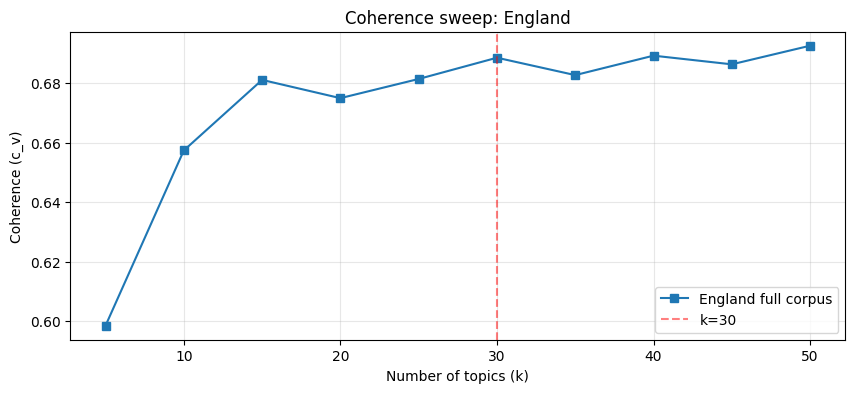

In [9]:
from model_pipeline.training.s07_evaluation import evaluate_coherence_over_topic_range
import matplotlib.pyplot as plt

texts_tokens = df["tokens_final"].tolist()

df_coh = evaluate_coherence_over_topic_range(
    X=vec_out.X,
    feature_names=vec_out.feature_names,
    texts_tokens=texts_tokens,
    topic_range=range(5, 55, 5),
    n_top_words=10,
    random_state=42,
    init="nndsvd",
    max_iter=1000,
)

print(df_coh.to_string(index=False))

plt.figure(figsize=(10, 4))
plt.plot(df_coh["n_topics"], df_coh["coherence_cv"], marker="s", label="England full corpus")
plt.axvline(x=30, color="red", linestyle="--", alpha=0.5, label="k=30")
plt.xlabel("Number of topics (k)")
plt.ylabel("Coherence (c_v)")
plt.title("Coherence sweep: England")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig("/workspaces/AM1_topic_modelling/data/evaluation_outputs/coherence_sweep_eng_k30.png", dpi=150, bbox_inches="tight")
print("Saved figure to data/evaluation_outputs/coherence_sweep_eng_k30.png")

plt.show()

#### Coherence across k: jumps sharply from k=5 (0.598) to k=15 (0.681) then plateaus through k=50 (0.693) — the metric cannot distinguish between 15 and 50 topics. This justifies k=5 and k=15 as comparison points. k=5 has detectably worse coherence yet still passes as usable while producing source proxies instead of policy themes. k=15 is statistically indistinguishable from k=30 (0.681 vs 0.689) yet the two models differ fundamentally in source concentration, topic distribution, and naming contestability. Coherence rewards mathematical fit, not analytical value — two models with identical coherence can produce different policy conclusions, and a model with poor coherence can still look credible to an end user. Standard quality metrics cannot substitute for specification transparency.


# 7. Topic stability across random seeds

In [10]:
seeds = [42, 123, 456, 789, 1024]
H_matrices = []

for seed in seeds:
    model = NMF(n_components=30, init="nndsvda", random_state=seed, max_iter=1000)
    model.fit(vec_out.X)
    H_matrices.append(model.components_)
    print(f"Seed {seed}: recon error = {model.reconstruction_err_:.4f}")

# Compare all pairs of H matrices
pair_scores = []
for i in range(len(seeds)):
    for j in range(i + 1, len(seeds)):
        sim = cosine_similarity(H_matrices[i], H_matrices[j])
        best_matches = sim.max(axis=1).mean()
        pair_scores.append(best_matches)
        print(f"Seeds {seeds[i]} vs {seeds[j]}: avg best-match similarity = {best_matches:.4f}")

avg_stability = np.mean(pair_scores)
print(f"\nOverall topic stability: {avg_stability:.4f}")
print(f"Interpretation: >0.90 = highly stable, 0.80-0.90 = acceptable, <0.80 = unstable")


Seed 42: recon error = 53.1420
Seed 123: recon error = 53.1831
Seed 456: recon error = 53.1523
Seed 789: recon error = 53.1618
Seed 1024: recon error = 53.1831
Seeds 42 vs 123: avg best-match similarity = 0.9524
Seeds 42 vs 456: avg best-match similarity = 0.9736
Seeds 42 vs 789: avg best-match similarity = 0.9512
Seeds 42 vs 1024: avg best-match similarity = 0.9533
Seeds 123 vs 456: avg best-match similarity = 0.9715
Seeds 123 vs 789: avg best-match similarity = 0.9492
Seeds 123 vs 1024: avg best-match similarity = 0.9998
Seeds 456 vs 789: avg best-match similarity = 0.9777
Seeds 456 vs 1024: avg best-match similarity = 0.9785
Seeds 789 vs 1024: avg best-match similarity = 0.9559

Overall topic stability: 0.9663
Interpretation: >0.90 = highly stable, 0.80-0.90 = acceptable, <0.80 = unstable


#### Topic stability at k=30: 0.966 across 5 random seeds — the first k where stability drops below 1.0. Reconstruction errors vary slightly (53.14–53.18), confirming multiple plausible solutions exist. Seed pair similarity ranges from 0.949 to 0.9998 — some pairs converge to near-identical solutions while others diverge. That variance is where the contestable topics live. At k≤15, stability is trivially perfect (1.0). At k=30, the factorisation is complex enough that initialisation matters. The transition between k=15 and k=30 marks where the model moves from having one obvious answer to having multiple plausible ones — and where specification choices start to matter most.


# 8. Inspect topics — top words per topic

In [11]:
topics = get_top_words_per_topic(nmf_out.nmf_model, vec_out.feature_names, n_top_words=100)

# Display stopwords — these don't affect the model, just make the top words easier to read
display_stop = {
    "school", "education", "pupil", "student", "teacher", "year", "new", "work",
    "time", "say", "make", "good", "need", "use", "know", "want", "come", "take",
    "people", "government", "report", "system", "support", "include", "provide",
    "number", "change", "part", "set", "high", "low", "level", "national", "local",
    "public", "service", "also", "would", "could", "one", "two", "first", "last",
    "week", "month", "day", "told", "said", "according", "cent", "per", "per cent",
    "child", "children", "young", "staff", "area", "programme", "policy",
    "guidance", "framework", "response", "statement", "proposal", "approach",
    "review", "update", "document", "detail", "section", "datum", "figure",
    "survey", "rate", "score", "point", "proportion", "percentage",
    "organisation", "department", "committee", "institute", "foundation",
    "summit", "voice", "stakeholder", "partnership", "engagement",
    "scheme", "initiative", "pilot", "introduce", "implement", "launch",
    "office", "official", "notification", "recipient", "correspondence",
    "cookie", "banner", "subscribe", "contact", "submit", "accessibility",
    "share", "print", "visit", "site", "experience", "article", "news", "blog",
    "interesting", "fact", "previous", "current", "date", "information",
    "different", "large", "place", "individual", "view", "analysis",
    "thing", "way", "job"
}

for i, words in enumerate(topics):
    filtered = [w for w in words if w not in display_stop and len(w) > 2][:30]
    print(f"\nTopic {i}: {', '.join(filtered)}")



Topic 0: family, care, child school, parent, life, early, school child, attendance, standard, poverty, country, child child, child education, social, child young, young people, social care, opportunity, vulnerable, sure, right, child social, classroom, speech, child poverty, parent child, great, child need, chance, educational

Topic 1: academy, authority education, late information, education skill, school academy, late, local authority, authority, skill, information action, assurance, skill vocational, vocational training, management assurance, academy funding, academy financial, assurance school, esfa, training school, provider education, financial management, education provider, management, esfa late, agency academy, vocational, action education, skill agency, college local, academy local

Topic 2: trust, academy, academy trust, mat, trust school, ceo, school trust, chain, trust academy, executive, financial, chief executive, multi academy, governance, merger, multi, finance, noti

# 9. Rename Topics 

In [12]:
NEW_TOPIC_NAMES = {
    0: "child_and_family_welfare",
    1: "academy_finance_and_oversight",
    2: "academy_trust_governance",
    3: "teacher_pay",
    4: "ofsted_inspection_reform",
    5: "gcse_grades_and_results",
    6: "pupil_disadvantage_and_attainment",
    7: "dfe_warning_notices",
    8: "send_and_council_deficits",
    9: "teacher_strikes_and_unions",
    10: "apprenticeships_and_skills",
    11: "ofqual_exam_regulation",
    12: "raac_building_crisis",
    13: "school_absence_and_attendance",
    14: "free_school_meals_and_poverty",
    15: "education_politics",
    16: "research_and_social_justice",
    17: "leadership_appointments",
    18: "mental_health_and_wellbeing",
    19: "post16_qualifications",
    20: "primary_assessment_and_sats",
    21: "safeguarding_and_complaints",
    22: "teacher_recruitment_and_retention",
    23: "school_funding",
    24: "curriculum_and_subjects",
    25: "ofsted_report_cards",
    26: "breakfast_clubs",
    27: "edtech_and_ai",
    28: "school_places_and_capacity",
    29: "exclusions_and_suspensions",
}

df["dominant_topic"] = nmf_out.W.argmax(axis=1)
df["dominant_topic_name"] = df["dominant_topic"].map(NEW_TOPIC_NAMES)
df["dominant_topic_name"].value_counts()


dominant_topic_name
academy_trust_governance             258
teacher_recruitment_and_retention    248
safeguarding_and_complaints          236
ofsted_inspection_reform             236
research_and_social_justice          196
school_funding                       180
education_politics                   169
post16_qualifications                153
academy_finance_and_oversight        149
leadership_appointments              140
send_and_council_deficits            140
curriculum_and_subjects              137
teacher_strikes_and_unions           128
ofsted_report_cards                  126
school_places_and_capacity           121
primary_assessment_and_sats          120
raac_building_crisis                 120
ofqual_exam_regulation               119
pupil_disadvantage_and_attainment    117
teacher_pay                          108
apprenticeships_and_skills            99
edtech_and_ai                         93
school_absence_and_attendance         87
dfe_warning_notices                  

## 10. Explore a topic - top articles + source concentration

In [13]:
def explore_topic(topic_id, n=5):
    """Show top N articles for a given topic, ranked by topic weight."""
    W = nmf_out.W
    topic_weights = W[:, topic_id]
    top_idx = topic_weights.argsort()[::-1][:n]

    # Topic words
    words = topics[topic_id]
    filtered = [w for w in words if w not in display_stop and len(w) > 2][:20]
    print(f"TOPIC {topic_id} ({NEW_TOPIC_NAMES[topic_id]}) — top words: {', '.join(filtered)}")
    print(f"{'='*120}\n")

    for rank, idx in enumerate(top_idx, 1):
        row = df.iloc[idx]
        weight = topic_weights[idx]
        title = row.get("title", "No title")
        source = row.get("source", "Unknown")
        date = str(row.get("article_date", ""))[:10]
        text = row.get("text_clean", row.get("text", ""))
        if isinstance(text, str) and len(text) > 500:
            text = text[:500] + "..."

        print(f"[{rank}] weight={weight:.4f} | {source} | {date}")
        print(f"    {title}")
        print(f"    {text}\n")

# Source concentration across all topics
print("Source concentration (top 50 articles per topic):")
print("=" * 80)
for t in range(nmf_out.nmf_model.n_components):
    top_idx = nmf_out.W[:, t].argsort()[::-1][:50]
    breakdown = df.iloc[top_idx]['source'].value_counts()
    pct = (breakdown / breakdown.sum() * 100).round(0).astype(int)
    summary = ", ".join(f"{src} {p}%" for src, p in pct.items())
    print(f"Topic {t:>2} ({NEW_TOPIC_NAMES[t]}): {summary}")

# Usage: explore_topic(0) for topic 0, explore_topic(3, n=10) for 10 articles


Source concentration (top 50 articles per topic):
Topic  0 (child_and_family_welfare): gov 50%, schoolsweek 38%, fed 4%, fft 4%, epi 4%
Topic  1 (academy_finance_and_oversight): gov 100%
Topic  2 (academy_trust_governance): schoolsweek 74%, gov 26%
Topic  3 (teacher_pay): schoolsweek 98%, gov 2%
Topic  4 (ofsted_inspection_reform): schoolsweek 82%, gov 12%, fft 6%
Topic  5 (gcse_grades_and_results): schoolsweek 52%, fft 32%, epi 10%, gov 6%
Topic  6 (pupil_disadvantage_and_attainment): fft 62%, schoolsweek 30%, epi 8%
Topic  7 (dfe_warning_notices): gov 100%
Topic  8 (send_and_council_deficits): schoolsweek 98%, gov 2%
Topic  9 (teacher_strikes_and_unions): schoolsweek 100%
Topic 10 (apprenticeships_and_skills): gov 78%, schoolsweek 20%, epi 2%
Topic 11 (ofqual_exam_regulation): gov 52%, schoolsweek 48%
Topic 12 (raac_building_crisis): schoolsweek 94%, epi 4%, gov 2%
Topic 13 (school_absence_and_attendance): fft 52%, schoolsweek 38%, epi 10%
Topic 14 (free_school_meals_and_poverty): sc

#### Source concentration at k=30: 14/30 topics are >90% single-source, 10/30 are multi-source (<70% top source). Government owns two complete monologues (academy finance 100%, DfE notices 100%). SchoolsWeek owns two (strikes 100%, politics 100%) plus dominates 10 more at 82–98%. Nuffield leads one topic entirely (research 86%) — invisible everywhere else, only visible because k=30 creates enough room. FFT concentrates in attainment/attendance (pupil disadvantage 62%, absence 52%, GCSE 32%). The surprising finding: single-source concentration goes back UP from k=15 (40%) to k=30 (47%). More topics doesn't mean more diversity — it means the model carves out source-specific niches. SchoolsWeek gets its own topics for strikes, politics, RAAC, funding. Source diversity and source specialisation increase simultaneously at higher k.


#### Topic naming sensitivity to keyword depth: Topic names vary depending on whether the top 20, 30, or 50 keywords are reviewed. At 20 keywords, names reflect the topic's core (e.g. "teacher_pay"); at 50, peripheral keywords pull names toward broader framings (e.g. "teacher_workforce_conditions"). Top 30 keywords were used as the default for both human and LLM review, balancing specificity with scope. This is itself a specification choice — the number of keywords shown to the reviewer shapes how the topic is understood and labelled.

#### Contestability implications of topic relabelling: 13/30 topics required relabelling after retraining on a <1% different corpus. The content did not change — the indices shuffled. This means topic labels are a specification choice, not a model output. A mislabelled topic (e.g. "send_provision" applied to council deficit keywords) would cause stakeholders to misinterpret cross-jurisdiction findings. Two researchers on near-identical data would produce identical coherence scores but different labels. Topic naming should be logged and audited as a specification decision alongside model parameters.

## 11. LLM-suggested topic names

Send top words per topic to Claude for naming suggestions. Compare with existing names.

In [14]:
import os
from pathlib import Path
from dotenv import load_dotenv
from anthropic import Anthropic
import json
import re

load_dotenv(Path("/workspaces/AM1_topic_modelling/.env"))
client = Anthropic(api_key=os.environ["ANTHROPIC_API_KEY"])

# Build keyword lists (without display stopwords)
topic_keyword_lines = []
for i, words in enumerate(topics):
    filtered = [w for w in words if w not in display_stop and len(w) > 2][:30]
    topic_keyword_lines.append(f"Topic {i}: {', '.join(filtered)}")

my_name_lines = []
for i in range(30):
    my_name_lines.append(f"Topic {i}: proposed name is '{NEW_TOPIC_NAMES.get(i, 'unknown')}'")

prompt = f"""You are helping label topics from an NMF topic model trained on UK education policy documents (2023-2025).
The corpus includes articles from government departments, think tanks, media outlets, and research organisations in England.
This model has k=30 topics.

STEP 1: For each topic below, suggest a name based ONLY on the keywords. Do not look ahead to Step 2.

{chr(10).join(topic_keyword_lines)}

For each topic return:
- suggested_name (2-4 words, snake_case)
- explanation (one sentence)

STEP 2: Now compare your suggestions against these human-proposed names for the same topics:

{chr(10).join(my_name_lines)}

For each topic, assess:
- proposed_name_assessment: "AGREE" (proposed name fits the keywords well), "CLOSE" (reasonable but could be more precise), or "DISAGREE" (proposed name doesn't capture the topic well)
- proposed_name_note: one sentence explaining why

Return ONLY a JSON list combining both steps:
[
  {{"topic": 0, "suggested_name": "name", "explanation": "why", "proposed_name_assessment": "AGREE", "proposed_name_note": "why"}},
  ...
]
No other text, no markdown, no code fences."""

response = client.messages.create(
    model="claude-sonnet-4-20250514",
    max_tokens=4096,
    messages=[{"role": "user", "content": prompt}],
)

llm_text = response.content[0].text

# Strip markdown code fences if present
cleaned = re.sub(r'^```(?:json)?\n?', '', llm_text.strip())
cleaned = re.sub(r'\n?```$', '', cleaned.strip())
llm_results = json.loads(cleaned)

# Summary table
print(f"{'Topic':>5}  {'My Name':<40}  {'Status':<8}  {'LLM Suggestion':<40}  Notes")
print("=" * 160)
for r in llm_results:
    i = r["topic"]
    mine = NEW_TOPIC_NAMES.get(i, "???")
    status = r.get('proposed_name_assessment', 'N/A') or 'N/A'
    suggestion = r.get('suggested_name', 'N/A') or 'N/A'
    note = r.get('proposed_name_note', 'N/A') or 'N/A'
    print(f"{i:>5}  {mine:<40}  {status:<8}  {suggestion:<40}  {note}")

# Detailed explanations
print("\n\nDETAILED EXPLANATIONS:")
print("=" * 80)
for r in llm_results:
    suggestion = r.get('suggested_name', 'N/A') or 'N/A'
    explanation = r.get('explanation', 'N/A') or 'N/A'
    status = r.get('proposed_name_assessment', 'N/A') or 'N/A'
    note = r.get('proposed_name_note', 'N/A') or 'N/A'
    print(f"\nTopic {r['topic']}: {suggestion}")
    print(f"  Why: {explanation}")
    print(f"  My name '{NEW_TOPIC_NAMES.get(r['topic'], '???')}': {status} — {note}")

# Save
with open("/workspaces/AM1_topic_modelling/data/evaluation_outputs/llm_topic_review_k30.json", "w") as f:
    json.dump(llm_results, f, indent=2)
print("\nSaved to data/evaluation_outputs/llm_topic_review_k30.json")


INFO:httpx:HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


Topic  My Name                                   Status    LLM Suggestion                            Notes
    0  child_and_family_welfare                  AGREE     child_family_welfare                      The proposed name accurately captures the focus on children's welfare and family support systems evident in the keywords.
    1  academy_finance_and_oversight             AGREE     academy_oversight_management              The proposed name effectively captures both the financial aspects and oversight mechanisms for academies shown in the keywords.
    2  academy_trust_governance                  AGREE     academy_trust_governance                  The proposed name perfectly matches the clear focus on academy trust structures and governance arrangements.
    3  teacher_pay                               AGREE     teacher_pay_awards                        The proposed name accurately reflects the clear focus on teacher compensation and pay-related issues.
    4  ofsted_inspection_ref

#### LLM naming validation at k=30: 29/30 AGREE, 1/30 CLOSE ("breakfast_clubs" vs "breakfast_clubs_wraparound"). Near-perfect agreement when naming fresh from keywords — topics are specific enough that reasonable reviewers converge. The real naming risk at k=30 is not disagreement — it's staleness. 13/30 topics required relabelling after retraining on a <1% different corpus because topic indices shuffled. The specification risk is not "can we name it?" but "will the name stay correct?" The naming layer at k=30 is fragile across model iterations, not across reviewers.


## 12. Topic distribution — how many articles per dominant topic?

In [15]:
dominant_topics = nmf_out.W.argmax(axis=1)
dominant_weights = nmf_out.W.max(axis=1)

topic_counts = pd.Series(dominant_topics).value_counts().sort_index()
topic_df = pd.DataFrame({
    "topic_num": topic_counts.index,
    "topic_name": [NEW_TOPIC_NAMES.get(i, "???") for i in topic_counts.index],
    "count": topic_counts.values,
    "pct": (topic_counts.values / len(dominant_topics) * 100).round(1),
})
print(topic_df.to_string(index=False))
print(f"\nDominant weight — min: {dominant_weights.min():.4f}, mean: {dominant_weights.mean():.4f}, max: {dominant_weights.max():.4f}")


 topic_num                        topic_name  count  pct
         0          child_and_family_welfare     60  1.5
         1     academy_finance_and_oversight    149  3.8
         2          academy_trust_governance    258  6.5
         3                       teacher_pay    108  2.7
         4          ofsted_inspection_reform    236  6.0
         5           gcse_grades_and_results     75  1.9
         6 pupil_disadvantage_and_attainment    117  3.0
         7               dfe_warning_notices     82  2.1
         8         send_and_council_deficits    140  3.6
         9        teacher_strikes_and_unions    128  3.2
        10        apprenticeships_and_skills     99  2.5
        11            ofqual_exam_regulation    119  3.0
        12              raac_building_crisis    120  3.0
        13     school_absence_and_attendance     87  2.2
        14     free_school_meals_and_poverty     82  2.1
        15                education_politics    169  4.3
        16       research_and_s

#### Topic distribution at k=30: well-distributed across 30 topics, range 1.1%–6.5%. No topic exceeds 7%. Top 5: academy trust governance (6.5%), teacher recruitment (6.3%), Ofsted inspection reform (6.0%), safeguarding (6.0%), research and social justice (5.0%). Smallest: breakfast clubs (1.1%), exclusions (1.3%), child welfare (1.5%) — these only exist because k=30 gives them room. Mean dominant weight 0.130, max 0.349 — the model is confident about most assignments. Child welfare shrank from a catch-all to one of the smallest topics as everything hidden inside it at lower k now has its own topic.


# 13. Topic distribution by source

Check if any source dominates a topic (specification choice: corpus composition).

In [16]:
df["dominant_topic"] = dominant_topics
df["dominant_topic_name"] = df["dominant_topic"].map(NEW_TOPIC_NAMES)
ct = pd.crosstab(df["source"], df["dominant_topic_name"], normalize="columns").round(2)
print("Source distribution per topic (column-normalised):")
ct


Source distribution per topic (column-normalised):


dominant_topic_name,academy_finance_and_oversight,academy_trust_governance,apprenticeships_and_skills,breakfast_clubs,child_and_family_welfare,curriculum_and_subjects,dfe_warning_notices,edtech_and_ai,education_politics,exclusions_and_suspensions,...,raac_building_crisis,research_and_social_justice,safeguarding_and_complaints,school_absence_and_attendance,school_funding,school_places_and_capacity,send_and_council_deficits,teacher_pay,teacher_recruitment_and_retention,teacher_strikes_and_unions
source,,,,,,,,,,,,,,,,,,,,,
epi,0.00,0.00,0.02,0.00,0.07,0.01,0.00,0.02,0.01,0.08,...,0.02,0.10,0.00,0.06,0.01,0.04,0.00,0.00,0.02,0.00
fed,0.00,0.00,0.05,0.07,0.05,0.07,0.00,0.11,0.01,0.00,...,0.00,0.18,0.01,0.00,0.00,0.01,0.01,0.00,0.01,0.00
fft,0.01,0.01,0.02,0.00,0.02,0.04,0.00,0.01,0.00,0.29,...,0.00,0.02,0.00,0.38,0.00,0.04,0.00,0.00,0.01,0.00
gov,0.99,0.10,0.61,0.28,0.47,0.18,0.96,0.23,0.01,0.00,...,0.10,0.04,0.11,0.09,0.08,0.03,0.04,0.03,0.07,0.04
nuffield,0.00,0.00,0.01,0.00,0.02,0.01,0.00,0.02,0.01,0.02,...,0.00,0.44,0.00,0.00,0.01,0.01,0.01,0.00,0.00,0.00
schoolsweek,0.00,0.88,0.29,0.65,0.38,0.70,0.04,0.61,0.96,0.62,...,0.88,0.21,0.88,0.47,0.90,0.87,0.95,0.97,0.89,0.96


#### Full normalised source-topic heatmap at k=30: confirms the Gov/SchoolsWeek binary — 11/30 topics have one source exceeding 88%. But the multi-source topics reveal genuine diversity: research/social justice has four meaningful voices (Nuffield 44%, SchoolsWeek 21%, FED 18%, EPI 10%). Child welfare is the most balanced Gov/SchoolsWeek split (47/38). FED shows clear niche interests in edtech (11%), research (18%), and breakfast clubs (7%) — a voice invisible in most analyses but present where it matters. The heatmap shows the English education policy landscape is not one debate but a set of parallel specialist monologues punctuated by a few genuinely contested spaces.


# 14. Save retrained model artifacts

In [17]:
import joblib
import json
from datetime import datetime

run_id = datetime.now().strftime("%Y-%m-%d_%H%M%S")
run_dir = Path(f"/workspaces/AM1_topic_modelling/experiments/outputs/runs/{run_id}")
run_dir.mkdir(parents=True, exist_ok=True)

# Save model + vectorizer
joblib.dump(nmf_out.nmf_model, run_dir / "nmf_model.joblib")
joblib.dump(vec_out.vectorizer, run_dir / "vectorizer.joblib")

# Save topic names
with open(run_dir / "topic_names.json", "w") as f:
    json.dump(NEW_TOPIC_NAMES, f, indent=2)

# Save run metadata
metadata = {
    "run_id": run_id,
    "model_id": "nmf_eng_30",
    "n_articles": len(df),
    "n_topics": 30,
    "init": "nndsvd",
    "random_state": 42,
    "max_iter": 1000,
    "reconstruction_error": float(nmf_out.reconstruction_error),
    "tfidf_min_df": 3,
    "tfidf_max_df": 0.85,
    "tfidf_max_features": 3000,
    "tfidf_ngram_range": [1, 2],
    "vocabulary_size": len(vec_out.feature_names),
    "topic_stability": float(avg_stability),
    "corpus": "eng_training_3943_supabase",
    "note": "England k=30 production model. Human-assigned topic names."
}
with open(run_dir / "run_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Saved to {run_dir}")
print(f"Contents: {[f.name for f in run_dir.iterdir()]}")


Saved to /workspaces/AM1_topic_modelling/experiments/outputs/runs/2026-03-24_131858
Contents: ['vectorizer.joblib', 'nmf_model.joblib', 'run_metadata.json', 'topic_names.json']


# 15. Save dashboard summary JSON (for Specification Sensitivity page)

In [21]:
import json

dominant = nmf_out.W.argmax(axis=1)

topic_data = []
for i in range(30):
    mask = dominant == i
    count = int(mask.sum())
    source_counts = df.loc[mask, "source"].value_counts()
    top_source = source_counts.index[0] if len(source_counts) > 0 else "unknown"
    top_source_pct = round(float(source_counts.iloc[0] / source_counts.sum()), 2) if len(source_counts) > 0 else 0

    topic_data.append({
        "topic_num": i,
        "name": NEW_TOPIC_NAMES[i],
        "count": count,
        "pct": round(count / len(df) * 100, 1),
        "top_source": top_source,
        "top_source_pct": top_source_pct,
        "single_source": top_source_pct > 0.90,
    })

summary = {
    "model_id": "nmf_eng_30",
    "n_topics": 30,
    "n_articles": len(df),
    "metrics": {
        "reconstruction_error": round(float(nmf_out.reconstruction_error), 4),
        "stability": round(float(avg_stability), 4),
        "mean_dominant_weight": round(float(nmf_out.W.max(axis=1).mean()), 4),
        "max_dominant_weight": round(float(nmf_out.W.max(axis=1).max()), 4),
    },
    "topics": topic_data,
}

out_path = "/workspaces/AM1_topic_modelling/data/evaluation_outputs/nmf_eng_30_summary.json"
with open(out_path, "w") as f:
    json.dump(summary, f, indent=2)

print(f"Saved to {out_path}")
print(f"Single-source topics: {sum(1 for t in topic_data if t['single_source'])}/30")


Saved to /workspaces/AM1_topic_modelling/data/evaluation_outputs/nmf_eng_30_summary.json
Single-source topics: 6/30


## Final Summary: England k=30 Production Model

This notebook trained the production NMF topic model on the England corpus (3,931 articles post-cleaning) at k=30. This is the baseline model for the AtlasED dashboard, Supabase, and all downstream analysis. Topic names were human-assigned after manual keyword review, with LLM validation confirming 29/30 names (1 rated CLOSE).

**30 well-distributed topics** ranging from 1.1% (breakfast clubs) to 6.5% (academy trust governance). No topic dominates. Mean dominant weight 0.130 — the model is confident about most assignments.

**Source concentration reveals parallel monologues, not conversation.** 14/30 topics are >90% single-source. Government owns regulatory topics (academy finance 100%, DfE notices 100%). SchoolsWeek owns contested policy debates (strikes 100%, politics 100%, plus 10 more at 82–98%). Nuffield leads research (86%). FFT concentrates in attainment/attendance (pupil disadvantage 62%, absence 52%). The English education policy landscape is a set of specialist monologues punctuated by a few genuinely multi-source spaces.

**Stability at k=30 is 0.966** — the first k where stability drops below 1.0. Some seed pairs converge to near-identical solutions (0.9998) while others diverge (0.949). This is where specification choices start to matter: multiple plausible solutions exist, and the one the model finds depends on initialisation.

**Coherence at k=30 is 0.689** — indistinguishable from k=15 (0.681) within the plateau band. The metric cannot distinguish between 15 and 50 topics, confirming that coherence alone is insufficient for choosing k.

**This model is one of four England variants** trained for the contestability demonstration. Comparing k=5, k=15, k=30, and k=30 no-media reveals that specification choices — topic count and source composition — determine what the model finds, whose voice is audible, and what conclusions a policymaker would reach. See `docs/internal/current/contestability/specification_sensitivity_findings.md` for the full cross-k analysis.
